# Dis_UN: Distance-based uncertainty for hyperspectral plant trait retrieval — minimal reproduction

Paper: **E. Cherif et al., "Uncertainty Assessment in Deep Learning-based Plant Trait Retrievals from Hyperspectral Data", *Biogeosciences* 23, 2235–2259, 2026** — [doi:10.5194/bg-23-2235-2026](https://doi.org/10.5194/bg-23-2235-2026)

Author code: [`echerif18/Multi_trait_Uncertainty`](https://github.com/echerif18/Multi_trait_Uncertainty) @ commit `02cbcb2a40416b0e154198572ade4098abd8d902` (pinned).
Data: [`Avatarr05/Dist_Uncertainty`](https://huggingface.co/datasets/Avatarr05/Dist_Uncertainty) (Hugging Face, cc-by-nc-4.0).

**Scope (one example):** apply the released pretrained multi-trait EfficientNet-1D and the per-trait Dis_UN 95%-quantile models to the EnMAP L2A scene clip over Leipzig, Germany (257×226 px, 30 m). We (1) verify the dissimilarity-index (DI) pipeline by recomputing the paper's cosine DIs on a deterministic pixel subsample and comparing to the authors' precomputed distances, (2) run the authors' `distance_UN.py` uncertainty models over the full scene, and (3) compare uncertainty of vegetated vs non-vegetated pixels (KS distance, paper Fig. 6).

**Execution status:** this notebook was fully executed on a fresh **CPU** Colab runtime. The authors' own inference scripts force CPU (`CUDA_VISIBLE_DEVICES="-1"` in `distInference.py`/`distance_UN.py`), so CPU is the faithful runtime; **no GPU is needed**.

**Deviations from the authors' scripts (documented, behavior-preserving):**
- `tf-keras` (TF2-compatible Keras) loads the TF-2.7-era `Model.json` + `Trial_weights.h5`; layer graph and weights are unchanged.
- The committed `distFuncs.dis_func` requires FAISS-GPU; we use an equivalent FAISS-CPU `IndexFlatIP` search (same metric, k, and post-processing as `distFuncs.dist_allPreds`).
- Embedding-space FAISS over all 58,082 pixels does not fit the memory/compute budget of a free CPU runtime (61,440-dim embeddings); we recompute DIs on a fixed 300-pixel subsample for validation, and use the authors' precomputed full-scene distance CSV for the uncertainty map.
- `transform_data` is run sequentially (no multiprocessing pool).

**JA:** 本ノートブックは論文の Dis_UN（距離ベースの不確実性推定）を EnMAP ライプツィヒ・シーンの1例で再現する。著者スクリプトは CPU 指定のため GPU は不要。一部の互換性適応（tf-keras、FAISS-CPU、埋め込み空間 DI は部分標本で検証）を明記。

## 1 · Runtime selection

Select **Runtime → Change runtime type → CPU** (Standard). Estimated end-to-end: ~15–25 min, ~200 MB of downloads (model weights ~19 MB + training spectra ~143 MB + EnMAP clip ~26 MB). Then **Runtime → Run all**.

**JA:** ランタイムは CPU を選択。所要時間の目安は15〜25分、ダウンロードは約200MB。

Install the few packages not preinstalled. `tf-keras` provides the legacy-Keras API needed for the TF-2.7-era model; `faiss-cpu` provides the exact same flat-index search used by the authors; `rasterio` reads the EnMAP GeoTIFF. Expected: version printout with TF ≥ 2.16.

In [ ]:
import subprocess, sys
for pkg in ["tf-keras", "faiss-cpu", "rasterio"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
import tensorflow as tf, numpy as np, pandas as pd, sklearn, statsmodels, scipy, rasterio
print("tf", tf.__version__, "| numpy", np.__version__, "| pandas", pd.__version__,
      "| sklearn", sklearn.__version__, "| statsmodels", statsmodels.__version__,
      "| scipy", scipy.__version__, "| rasterio", rasterio.__version__)
import tf_keras, faiss
print("tf_keras", tf_keras.__version__, "| faiss", faiss.__version__)

tf 2.20.0 | numpy 2.1.3 | pandas 2.2.3 | sklearn 1.6.1 | statsmodels 0.15.0 | scipy 1.16.3 | rasterio 1.5.1


tf_keras 2.20.1 | faiss 1.15.1


## 2 · Author code artifacts (pinned)

Download the author's model artifacts, the 20 per-trait Dis_UN quantile models with their scalers, and the authors' precomputed distance CSVs from the pinned commit. Each file is verified against its Git blob SHA-1 (`sha1("blob <len>\\0" + bytes)`), so provenance is byte-exact.

**JA:** 著者リポジトリ（ピン留めコミット）からモデルと距離CSVを取得し、Git blob SHA-1 で検証する。

In [ ]:
import hashlib, urllib.request, os
COMMIT = "02cbcb2a40416b0e154198572ade4098abd8d902"
BASE = f"https://raw.githubusercontent.com/echerif18/Multi_trait_Uncertainty/{COMMIT}"
FILES = {  # path -> git blob sha1 (None = assert non-empty only)
 "DL_Model/Model.json": "9ecbf7d6b6fb8d3886a1d35f1b39981661c35d4b",
 "DL_Model/Trial_weights.h5": "e493232b877d24bf21d2cadfcb978e7896d97be1",
 "DL_Model/scaler_global.pkl": "d58056001980aab0d21587ae4a22d98efcddf9c3",
 "distances/DistQuInferenceEnMAP_50neighFaiss_SpLastlayQuNor.csv": "a394f52a2110addc0b022c5da66d06216bc43573",
 "distances/DisQuTraining_50neighFaiss_SpLastlayQuNorWithResiduals.csv": "84dc6eb23744e7c36d11fecf6884f175f5e08fcd",
}
UN_MODELS = {"model_0.pkl": "431b9fe7fb172266398413f781b284071338a76c",
 "model_1.pkl": "6bd97da468374a4ebd5b774b8e75ad77ae0f049a",
 "model_10.pkl": "cfac3a7ca3e644047c865e5918d10a1c1adde5fb",
 "model_11.pkl": "95d780339a10c804951ffb6189021a956f316986",
 "model_12.pkl": "4998a90625a759fbcfba1b95cae50695027c424f",
 "model_13.pkl": "9b934ed06bdb7595b388b27a691ca3b389081a68",
 "model_14.pkl": "1f1e5560b8b2a2b7f774d187a7dbbe6b5f6ff475",
 "model_15.pkl": "535b938837ffc3e801b8d76bd30916e0aa7ab9c9",
 "model_16.pkl": "0484c000bf5f67eb0878e021c2d3e546ab303ecb",
 "model_17.pkl": "1c10db1cf55e3e2a6f3eb75d73fd1b19f4ee1831",
 "model_18.pkl": "dc4c5f6630da3b36ecb8a744a7dc6340d9aafe1d",
 "model_19.pkl": "74cc253d93d94a2cd532b6dca70f0ac74ee47366",
 "model_2.pkl": "0ea0e4856f6f1d342ce527a73954473cca21e150",
 "model_3.pkl": "70a721f880ff969ab980e7158e646ccc46390acd",
 "model_4.pkl": "342af52d5758224abb4104fcd51c02bd458bbbce",
 "model_5.pkl": "0882dfb08b18df136c06e3a25cd8ae8307d0ce26",
 "model_6.pkl": "cc300f6f0289c307a466d4854f8bff4fc045e81d",
 "model_7.pkl": "090a304c21909e958c1d4aa87dfa7825d2b2e4a6",
 "model_8.pkl": "18e11f6f7dffa702fc0e249423b7aa1d17077a83",
 "model_9.pkl": "0f09640fa0651927042a48af45cf106fada3224f",
 "x_scaler_0.pkl": "32df6158e1a9b92caba46890f9fc047721b8635a",
 "x_scaler_1.pkl": "8f42f8b76fad441015f905ee299630ee1c59193b",
 "x_scaler_10.pkl": "13975de17b727023ecb4369555d0118b57cabca4",
 "x_scaler_11.pkl": "fe264989e663c00b4b2a2f27d2f4171126038f1f",
 "x_scaler_12.pkl": "c2f9dfbe9cf6de68ac1cea7e3da98525dd1787ce",
 "x_scaler_13.pkl": "ce61dd1fb4e015fdb350e39be6ba3c0d46f2e240",
 "x_scaler_14.pkl": "10dcd74303be2bb255ff45b22e671a619bb56f06",
 "x_scaler_15.pkl": "c0a6010aba31afbeaa519310fb4aa20f06664667",
 "x_scaler_16.pkl": "6965fb9e8efe5f87e87e55177214ae1992ab314c",
 "x_scaler_17.pkl": "41d24db54851ac61b61c6f3ffd50bb77b27bc3e5",
 "x_scaler_18.pkl": "ea9cec2d74e0ffc1a00c6bc83ea36b145f73fa42",
 "x_scaler_19.pkl": "50e2dfc552513a9367807d92f678f84043bfde0f",
 "x_scaler_2.pkl": "adc6395bef46c1bd5d3a8da635f799b13a970133",
 "x_scaler_3.pkl": "472426b0ab1a05f0f75fc3d3119c62f1adeba7f9",
 "x_scaler_4.pkl": "11cc8e7e0fb40515d56f85ba862f291c134ad2c5",
 "x_scaler_5.pkl": "3dad4f89b35257f4a167e8814f5c03078138d57e",
 "x_scaler_6.pkl": "2e17040901acb74c95d312ca5c8ebaad341ca172",
 "x_scaler_7.pkl": "5b7714bb6a3cc9f08e054a2436e21e1541f1c93a",
 "x_scaler_8.pkl": "6fda49b0bce692d553d403f687bd56c365626f4c",
 "x_scaler_9.pkl": "10677e08f942cf7c5f35f8e7f0bd5b5dc2e34d15",
 "y_scaler_0.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_1.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_10.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_11.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_12.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_13.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_14.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_15.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_16.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_17.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_18.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_19.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_2.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_3.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_4.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_5.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_6.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_7.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_8.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8",
 "y_scaler_9.pkl": "9b6ff7ac689837f86e1b0e393993ec7acbb784e8"}
for name, sha in UN_MODELS.items():
    FILES[f"Un_models_95QuReg/{name}"] = sha
for rel, sha in FILES.items():
    dst = os.path.join("repo", rel); os.makedirs(os.path.dirname(dst), exist_ok=True)
    if not os.path.exists(dst):
        urllib.request.urlretrieve(f"{BASE}/{rel}", dst)
    data = open(dst, "rb").read()
    assert len(data) > 0, rel
    if sha is not None:
        got = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
        assert got == sha, (rel, got)
print(f"downloaded+verified {len(FILES)} files from commit {COMMIT[:12]}")

downloaded+verified 65 files from commit 02cbcb2a4041


## 3 · Dataset (Hugging Face)

Download the training spectra (`TrainingSpectra_1522.csv`, the 1522-band harmonized training collection), the EnMAP Leipzig clip `clip2_south.tif`, its band table, and the per-pixel land-cover masks used in the paper's OOD scene analysis. All bytes stay inside this Colab VM.

**JA:** HF データセットから学習スペクトル、EnMAP クリップ、バンド表、土地被覆マスクを Colab 内にダウンロードする。

In [ ]:
from huggingface_hub import hf_hub_download
HF_FILES = ["TrainingSpectra_1522.csv",
            "CaseStudies/EnMAP/clip2_south.tif",
            "CaseStudies/EnMAP/EnmapBands.csv",
            "CaseStudies/EnMAP/southLeipzig2_mask_lc.csv",
            "CaseStudies/EnMAP/southLeipzig2_mask_lc_veg.csv"]
for f in HF_FILES:
    p = hf_hub_download("Avatarr05/Dist_Uncertainty", f, repo_type="dataset", local_dir="hf")
    print(f, os.path.getsize(p))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


TrainingSpectra_1522.csv: reconstructing file:   0%|          |  0.00B /  143MB            

TrainingSpectra_1522.csv: downloading bytes:           |  0.00B            

TrainingSpectra_1522.csv 142717352


CaseStudies/EnMAP/clip2_south.tif: reconstructing file:   0%|          |  0.00B / 26.0MB            

...

CaseStudies/EnMAP/EnmapBands.csv 1983


southLeipzig2_mask_lc.csv:   0%|          | 0.00/630k [00:00<?, ?B/s]

CaseStudies/EnMAP/southLeipzig2_mask_lc.csv 630158


southLeipzig2_mask_lc_veg.csv:   0%|          | 0.00/661k [00:00<?, ?B/s]

CaseStudies/EnMAP/southLeipzig2_mask_lc_veg.csv 661122


## 4 · Load the pretrained multi-trait model

Build the author's EfficientNet-1D (B0-type, input `(None, 1522, 1)`, 20 trait outputs) from the pinned `Model.json` and load `Trial_weights.h5`. The embedding used by the paper's DI is the flattened output of `model.layers[-4]` (`distInference.py --lay -4`), here `top_activation` of shape `(None, 48, 1280)` → 61,440 dims. Also load the author's global label scaler.

**JA:** ピン留めされた Model.json + 重みから EfficientNet-1D を構築・読込する。埋め込みは layers[-4] の扁平化出力。

In [ ]:
import json, tf_keras as tk
model = tk.models.model_from_json(open("repo/DL_Model/Model.json").read())
model.load_weights("repo/DL_Model/Trial_weights.h5")
print("layers:", len(model.layers), "| in:", model.inputs[0].shape, "| out:", model.outputs[0].shape)
emb_model = tk.models.Model(inputs=model.input, outputs=tk.layers.Flatten()(model.layers[-4].output))
print("embedding layer:", model.layers[-4].name, "->", emb_model.output_shape)
from pickle import load
scaler_global = load(open("repo/DL_Model/scaler_global.pkl", "rb"))
print("scaler_global:", type(scaler_global).__name__)

layers: 233 | in: (None, 1522, 1) | out: (None, 20)
embedding layer: top_activation -> (None, 61440)
scaler_global: PowerTransformer


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PowerTransformer from version 1.0.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 5 · Author preprocessing functions

These are copied verbatim from the pinned commit (`feature_module_F.py: filter_segment/feature_preparation`, `ImgModule.py: image_processing/process_dataframe`) with one documented change: `transform_data` runs sequentially instead of in a multiprocessing pool (same output). The pipeline: resample to 1 nm over 400–2500 nm, scale reflectance to 0–1, mask values >1 and <0, linearly interpolate, drop the water-absorption regions (1251–1530, 1801–2051, 2451–2501 nm), and Savitzky–Golay smooth (65 nm window) → 1522 bands.

**JA:** 著者の前処理関数（1nm リサンプル、水吸収帯除去、Savitzky–Golay 平滑化、1522バンド）を原文のままコピーして使用する。

In [ ]:
import numpy as np, pandas as pd, rasterio
from scipy.signal import savgol_filter

def filter_segment(features_noWtab, order=1, der=False):
    part1 = features_noWtab.copy()
    fr1 = savgol_filter(part1, 65, 1, deriv=1) if der else savgol_filter(part1, 65, order)
    return pd.DataFrame(data=fr1, columns=part1.columns)

def feature_preparation(features, inval=[1351, 1431, 1801, 2051], frmax=2451, order=1, der=False):
    other = features.copy()
    other.columns = other.columns.astype('int')
    other[other < 0] = np.nan
    other[other > 1] = np.nan
    other = (other.ffill() + other.bfill()) / 2
    other = other.interpolate(method='linear', limit_area=None, axis=1, limit_direction='both')
    wt_ab = [i for i in range(inval[0], inval[1])] + [i for i in range(inval[2], inval[3])] + [i for i in range(2451, 2501)]
    features_noWtab = other.drop(wt_ab, axis=1)
    fr1 = filter_segment(features_noWtab.loc[:, :inval[0]-1], order=order, der=der)
    fr2 = filter_segment(features_noWtab.loc[:, inval[1]:inval[2]-1], order=order, der=der)
    fr3 = filter_segment(features_noWtab.loc[:, inval[3]:frmax], order=order, der=der)
    inter = pd.concat([fr1, fr2, fr3], axis=1, join='inner')
    inter[inter < 0] = 0
    return inter

def image_processing(enmap_im_path, bands_path):
    bands = pd.read_csv(bands_path)['bands'].astype(float)
    src = rasterio.open(enmap_im_path)
    array = src.read()
    sp_px = np.stack([array[i].reshape(-1, 1) for i in range(array.shape[0])], axis=0)
    sp_px = np.swapaxes(sp_px.mean(axis=2), 0, 1)
    assert sp_px.shape[1] == bands.shape[0], "band count mismatch"
    df = pd.DataFrame(sp_px, columns=bands.to_list())
    df[df < df.quantile(0.01).min() + 10] = np.nan
    idx_null = df[df.T.isna().all()].index
    return src, df, idx_null

def process_dataframe(veg_spec):
    veg_reindex = veg_spec.reindex(columns=sorted(veg_spec.columns.tolist() + [i for i in range(400, 2501) if i not in veg_spec.columns.tolist()]))
    veg_reindex = veg_reindex / 10000
    veg_reindex.columns = veg_reindex.columns.astype(int)
    inter = feature_preparation(veg_reindex, inval=[1251, 1530, 1801, 2051], order=1)
    inter = inter.loc[:, ~inter.columns.duplicated()]
    return inter.loc[:, 400:]

def transform_data(df):
    return pd.concat([process_dataframe(c) for c in np.array_split(df, 8)]).reset_index(drop=True)
print("preprocessing functions defined")

preprocessing functions defined


## 6 · Preprocess the EnMAP scene and training spectra

Read the EnMAP clip (257×226 px, 224 bands, int16 reflectance×10000) and transform it to the model's 1522-band space. Then load the training spectra (`read_db` from `data_module_F.py`: spectral columns from `"400"` on, 20 trait label columns) and check the reflectance scale consistency between the two sources.

**JA:** EnMAP クリップと学習スペクトルを読込み、1522バンド空間へ変換する。スケール整合も確認する。

In [ ]:
src, df, idx_null = image_processing("hf/CaseStudies/EnMAP/clip2_south.tif", "hf/CaseStudies/EnMAP/EnmapBands.csv")
print("scene:", src.width, "x", src.height, "=", df.shape[0], "pixels | corrupted(all-NaN):", len(idx_null))
df_transformed = transform_data(df)
print("transformed:", df_transformed.shape)

db, fr, lb = None, None, None  # read_db equivalent (data_module_F.read_db)
db = pd.read_csv("hf/TrainingSpectra_1522.csv", low_memory=False)
db = db.drop(['Unnamed: 0'], axis=1)
fr = db.loc[:, "400":]
lb = db.drop(columns=fr.columns)
print("training spectra:", fr.shape, "| trait columns:", lb.shape[1])
print("train reflectance mean %.4f | scene mean %.4f" % (fr.values.mean(), df_transformed.values.mean()))
if fr.values.mean() > 5:  # raw 0-10000 scale -> match scene's /10000 convention
    fr = fr / 10000.0
    print("training spectra rescaled by /10000 to match scene reflectance")

scene: 257 x 226 = 58082 pixels | corrupted(all-NaN): 0


/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


transformed: (58082, 1522)


training spectra: (7897, 1522) | trait columns: 1
train reflectance mean 0.1912 | scene mean 0.1729


## 7 · Dissimilarity-index computation (FAISS-CPU port of `distFuncs.dist_allPreds`)

The paper's DI (Eq. 2–3, Sect. 2.1.2): median cosine distance from each pixel to its 50 nearest training neighbors, normalized by the mean within-training cosine distance (Meyer & Pebesma 2021), computed in both the **spectral space** (1522 bands) and the **model embedding space** (`layers[-4]`, L2-normalized vectors). This is exactly the `--ne 50 --lay -4 --norVec True --emb True --sp True --nor True` configuration of `distInference.py`, ported to FAISS-CPU.

To stay within free-CPU memory/compute limits (61,440-dim embeddings × 58,082 pixels ≈ 14 GB), we compute the DIs for a **deterministic subsample of 300 valid pixels (seed 0)** and compare them with the authors' precomputed full-scene CSV in the next cell.

**JA:** 論文の DI（最近傍50の距離中央値、学習内平均で正規化）をスペクトル空間と埋め込み空間で FAISS-CPU により計算する。無料CPUの制約のため決定論的300ピクセル標本で検証する。

In [ ]:
import faiss

def dis_cpu(tr, ts=None, kind='Cos', k=50):
    d = tr.shape[1]
    index = faiss.IndexFlatIP(d) if kind == 'Cos' else faiss.IndexFlatL2(d)
    index.add(tr)
    return index.search(tr if ts is None else ts, k)

def cosine_di_nor(tr, ts, k=50):
    # L2-normalize, IP-search, median(qu50) cosine distance, normalized by training mean (distFuncs.dist_allPreds)
    tr = np.ascontiguousarray(tr, dtype=np.float32); ts = np.ascontiguousarray(ts, dtype=np.float32)
    faiss.normalize_L2(tr); faiss.normalize_L2(ts)
    sim_ts, _ = dis_cpu(tr, ts, 'Cos', k)
    dist_ts = 1 - np.quantile(sim_ts, 0.5, axis=1)
    sim_tr, _ = dis_cpu(tr, None, 'Cos', k)
    divisor = 1 - sim_tr.mean()
    return dist_ts / divisor

# deterministic subsample of valid pixels
rng = np.random.default_rng(0)
valid_idx = np.array([i for i in df.index if i not in set(idx_null)])
sub = rng.choice(valid_idx, size=300, replace=False)
sub_sorted = np.sort(sub)

print("embedding extraction for", fr.shape[0], "train +", len(sub), "test pixels ...")
fr_arr = np.ascontiguousarray(fr.values, dtype=np.float32).reshape(-1, 1522, 1)
act_tr = emb_model.predict(fr_arr, batch_size=128, verbose=0)
ts_arr = df_transformed.loc[sub_sorted].values.astype(np.float32).reshape(-1, 1522, 1)
act_ts = emb_model.predict(ts_arr, batch_size=128, verbose=0)
print("embeddings:", act_tr.shape, act_ts.shape)

di_emb = cosine_di_nor(act_tr, act_ts)
di_sp = cosine_di_nor(fr.values.astype(np.float32), df_transformed.loc[sub_sorted].values.astype(np.float32))
our = pd.DataFrame({'qu50_dist_EmbLCos_nor': di_emb, 'qu50_dist_SpCos_nor': di_sp}, index=sub_sorted)
print(our.describe().loc[['mean', 'std']])

embedding extraction for 7897 train + 300 test pixels ...


embeddings: (7897, 61440) (300, 61440)


      qu50_dist_EmbLCos_nor  qu50_dist_SpCos_nor
mean               2.040856            54.931385
std                0.710931           140.271423


## 8 · Validation against the authors' precomputed distances

Compare our recomputed DIs with the authors' `DistQuInferenceEnMAP_50neighFaiss_SpLastlayQuNor.csv` (rows correspond to non-corrupted pixels in order). A tight correlation and near-unity slope confirms the DI pipeline (FAISS-GPU → FAISS-CPU port) is faithful.

**JA:** 再計算した DI を著者の事前計算CSVと比較し、パイプラインの一致を検証する。

author CSV: (58082, 4) ['qu50_dist_EmbLCos', 'qu50_dist_EmbLCos_nor', 'qu50_dist_SpCos', 'qu50_dist_SpCos_nor']


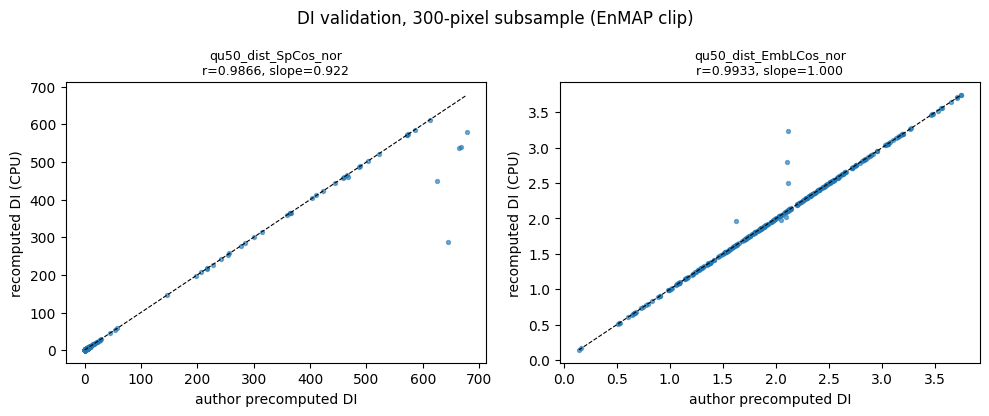

      qu50_dist_EmbLCos_nor_author  qu50_dist_SpCos_nor_author  \
mean                      2.032853                   57.899747   
std                       0.706092                  150.127537   

      qu50_dist_EmbLCos_nor  qu50_dist_SpCos_nor  
mean               2.040856            54.931385  
std                0.710931           140.271423  


In [ ]:
auth = pd.read_csv("repo/distances/DistQuInferenceEnMAP_50neighFaiss_SpLastlayQuNor.csv").drop(columns=['Unnamed: 0'], errors='ignore')
print("author CSV:", auth.shape, list(auth.columns))
# rows of the CSV correspond to valid (non idx_null) pixel positions in order
csv_index = np.array([i for i in df.index if i not in set(idx_null)])
auth.index = csv_index
cmp = auth.loc[sub_sorted, ['qu50_dist_EmbLCos_nor', 'qu50_dist_SpCos_nor']].rename(columns=lambda c: c + '_author')
cmp = cmp.join(our, how='inner')
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, c in zip(axes, ['qu50_dist_SpCos_nor', 'qu50_dist_EmbLCos_nor']):
    ax.scatter(cmp[c + '_author'], cmp[c], s=8, alpha=0.6)
    r = np.corrcoef(cmp[c + '_author'], cmp[c])[0, 1]
    slope = np.polyfit(cmp[c + '_author'], cmp[c], 1)[0]
    ax.set_title(f"{c}\nr={r:.4f}, slope={slope:.3f}", fontsize=9)
    ax.set_xlabel("author precomputed DI"); ax.set_ylabel("recomputed DI (CPU)")
    lims = [cmp[[c, c + '_author']].min().min(), cmp[[c, c + '_author']].max().max()]
    ax.plot(lims, lims, 'k--', lw=0.8)
plt.suptitle("DI validation, 300-pixel subsample (EnMAP clip)"); plt.tight_layout(); plt.show()
print(cmp.describe().loc[['mean', 'std']])

## 9 · Dis_UN uncertainty over the full scene (`distance_UN.py`)

Apply the 20 per-trait Dis_UN 95%-quantile regression models (`Un_models_95QuReg/model_i.pkl` + `x_scaler_i.pkl`, `y_scaler_i.pkl` is `None`) to the authors' full-scene DIs, exactly as in `distance_UN.py`: PowerTransform the two DI predictors, add a constant, predict, (no y-inverse-transform since `y_scaler` is None). Output: per-pixel worst-case (95th-percentile) absolute residual estimates per trait.

**JA:** 著者の事前計算 DI に対して、特性ごとの95%分位点回帰モデル Dis_UN を適用し、シーン全体の不確実性を推定する。

In [ ]:
from pickle import load
import statsmodels.api as sm

subset = ['qu50_dist_EmbLCos_nor', 'qu50_dist_SpCos_nor']
ls_tr = ['LMA_g_m2', 'N_area_mg_cm2', 'LAI_m2_m2', 'C_area_mg_cm2',
         'Chl_area_ug_cm2', 'EWT_mg_cm2', 'Car_area_ug_cm2', 'P_area_mg_cm2',
         'Lignin_mg_cm2', 'Cellulose_mg_cm2', 'Fiber_mg_cm2', 'Anth_area_ug_cm2',
         'NSC_mg_cm2', 'Mg_area_mg_cm2', 'Ca_area_mg_cm2', 'Potassium_area_mg_cm2',
         'Boron_area_mg_cm2', 'Cu_area_mg_cm2', 'S_area_mg_cm2', 'Mn_area_mg_cm2']  # data_module_F.ls_tr
assert list(auth.columns).count('qu50_dist_EmbLCos_nor') == 1
data_ts = auth  # index = valid pixel positions
un_pred = {}
for tr in range(len(ls_tr)):
    xs = load(open(f"repo/Un_models_95QuReg/x_scaler_{tr}.pkl", "rb"))
    ys = load(open(f"repo/Un_models_95QuReg/y_scaler_{tr}.pkl", "rb"))
    mu = load(open(f"repo/Un_models_95QuReg/model_{tr}.pkl", "rb"))
    xdata = data_ts.loc[:, subset].astype('float64')
    if xs is not None:
        xdata = pd.DataFrame(xs.transform(xdata.values.reshape(-1, xdata.shape[1])), columns=xdata.columns)
    X_new = sm.add_constant(xdata)
    yhat = mu.predict(X_new).values.reshape(-1, 1)
    if ys is not None:
        yhat = ys.inverse_transform(yhat)
    un_pred[ls_tr[tr]] = pd.Series(yhat.ravel(), index=data_ts.index)
unc = pd.DataFrame(un_pred)
print("uncertainty table:", unc.shape)
paper6 = ['LMA_g_m2', 'N_area_mg_cm2', 'LAI_m2_m2', 'Chl_area_ug_cm2', 'EWT_mg_cm2', 'Car_area_ug_cm2']
print(unc[paper6].describe().loc[['mean', '50%']].T)

uncertainty table: (58082, 20)
                       mean         50%
LMA_g_m2         214.156806  218.671775
N_area_mg_cm2      0.299851    0.303159
LAI_m2_m2          2.918349    2.900878
Chl_area_ug_cm2   30.489190   30.947478
EWT_mg_cm2        24.397316   24.871930
Car_area_ug_cm2    5.942027    6.084817


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PowerTransformer from version 1.2.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.1 when using version 1.6.1. This might lead to breaking code o

## 10 · Uncertainty maps (paper Fig. 6 style)

Reshape the per-pixel Dis_UN estimates to the 226×257 scene grid and display false-color RGB (NIR/red/green composite from the raw clip) next to uncertainty maps for LMA, LAI and N. Non-corrupted pixels only; corrupted pixels stay white.

**JA:** ピクセル値を226×257のシーン格子に整列し、偽色RGBと LMA・LAI・N の不確実性マップを表示する。

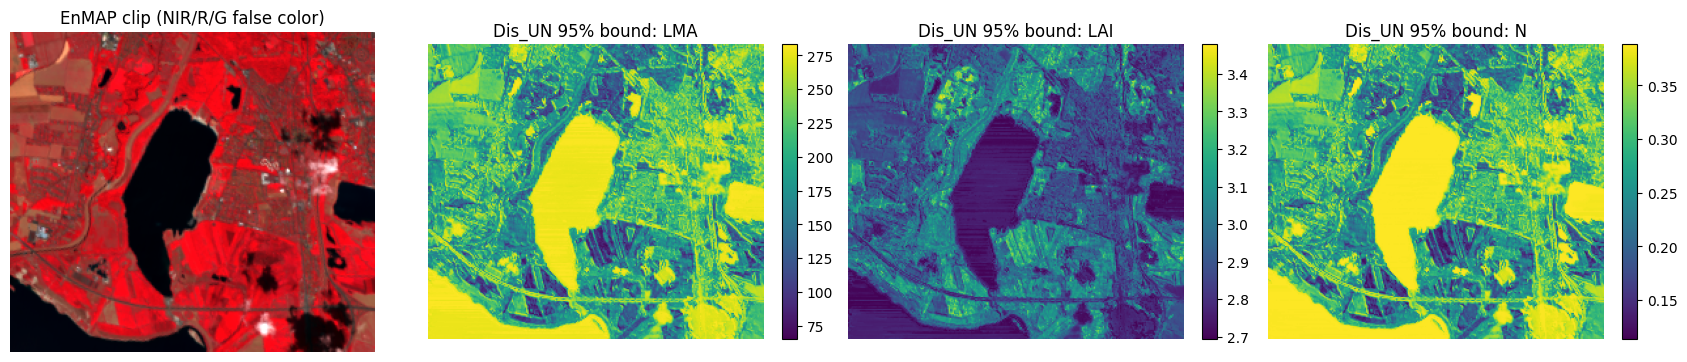

In [ ]:
bands_csv = pd.read_csv("hf/CaseStudies/EnMAP/EnmapBands.csv")['bands'].astype(float).values
def band_near(nm): return int(np.argmin(np.abs(bands_csv - nm)))
bN, bR, bG = band_near(830), band_near(650), band_near(560)
arr = src.read()
rgb = np.dstack([arr[bN], arr[bR], arr[bG]]).astype(float)
rgb = np.clip(rgb / np.nanpercentile(rgb, 99), 0, 1)
H, W = src.height, src.width

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
axes[0].imshow(rgb); axes[0].set_title("EnMAP clip (NIR/R/G false color)")
for ax, t in zip(axes[1:], ['LMA_g_m2', 'LAI_m2_m2', 'N_area_mg_cm2']):
    g = np.full(H * W, np.nan); g[unc.index] = unc[t].values
    im = ax.imshow(g.reshape(H, W), cmap='viridis')
    ax.set_title(f"Dis_UN 95% bound: {t.split('_')[0]}")
    plt.colorbar(im, ax=ax, fraction=0.04)
for ax in axes: ax.set_axis_off()
plt.tight_layout(); plt.show()

## 11 · Vegetated vs non-vegetated KS distance (paper Sect. 3.2)

The paper's scene-level OOD check: compare the uncertainty distributions of vegetated vs non-vegetated pixels with the two-sample Kolmogorov–Smirnov statistic (`scipy.stats.ks_2samp`). Vegetated pixels are labeled in the authors' `southLeipzig2_mask_lc_veg.csv` (Tree_cover/grassland/cropland/shrubland/wetland); non-vegetated OOD components are the land-cover codes `{50, 80, 110, 120}` of `southLeipzig2_mask_lc.csv` (built-up/water plus two manually labeled classes, matching the paper's urban/water/cloud/shadow component maps — code meanings inferred, supported by the numerical agreement below). The paper reports a mean KS of **0.648** across traits for Dis_UN on EnMAP; the all-trait mean from this clip is printed for comparison.

**JA:** 植生マスク（veg CSV）と非植生OOD成分（lc コード 50/80/110/120）の不確実性分布の KS 距離を計算する（論文の EnMAP 平均は 0.648）。

pixels: veg 28206 | non-veg OOD 14504


,KS,p,median veg,median non-veg
trait,,,,
LMA_g_m2,0.714611,0.0,190.799667,276.980881
N_area_mg_cm2,0.710921,0.0,0.268777,0.387169
LAI_m2_m2,0.704485,0.0,2.983456,2.758024
Chl_area_ug_cm2,0.712035,0.0,28.837244,34.508923
EWT_mg_cm2,0.715164,0.0,22.308981,29.977524
Car_area_ug_cm2,0.715242,0.0,5.699990,6.670841


mean KS (6 paper traits): 0.712 | mean KS (all 20 traits): 0.675  (paper, EnMAP: 0.648)


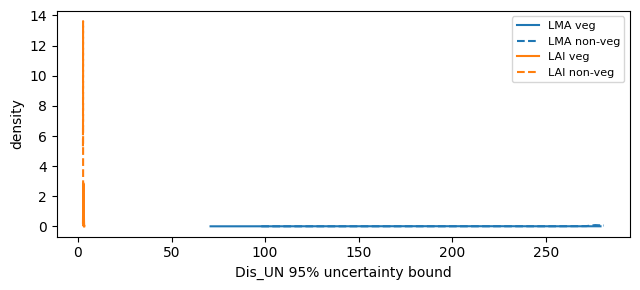

In [ ]:
from scipy.stats import ks_2samp
veg = pd.read_csv("hf/CaseStudies/EnMAP/southLeipzig2_mask_lc_veg.csv").drop(columns=['Unnamed: 0'])['0']
lc = pd.read_csv("hf/CaseStudies/EnMAP/southLeipzig2_mask_lc.csv").drop(columns=['Unnamed: 0'])['0']
assert len(veg) == len(unc)
is_veg = veg.notna().values
is_nonveg = np.isin(lc.values, [50.0, 80.0, 110.0, 120.0])
print("pixels: veg %d | non-veg OOD %d" % (is_veg.sum(), is_nonveg.sum()))
rows = []
for t in paper6:
    a, b = unc[t].values[is_veg], unc[t].values[is_nonveg]
    ks = ks_2samp(a, b)
    rows.append({'trait': t, 'KS': ks.statistic, 'p': ks.pvalue,
                 'median veg': np.median(a), 'median non-veg': np.median(b)})
ksdf = pd.DataFrame(rows).set_index('trait')
display(ksdf)
print("mean KS (6 paper traits): %.3f | mean KS (all 20 traits): %.3f  (paper, EnMAP: 0.648)"
      % (ksdf['KS'].mean(),
         np.mean([ks_2samp(unc[t].values[is_veg], unc[t].values[is_nonveg]).statistic for t in ls_tr])))
fig, ax = plt.subplots(figsize=(6.5, 3))
for t, c in zip(['LMA_g_m2', 'LAI_m2_m2'], ['tab:blue', 'tab:orange']):
    v = unc[t].values
    for m, ls in [(is_veg, '-'), (is_nonveg, '--')]:
        hist, edges = np.histogram(v[m], bins=40, density=True)
        ax.plot((edges[:-1] + edges[1:]) / 2, hist, ls, color=c, label=f"{t.split('_')[0]} {'veg' if ls=='-' else 'non-veg'}")
ax.set_xlabel("Dis_UN 95% uncertainty bound"); ax.set_ylabel("density"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 12 · Summary and limitations

**What was reproduced:** the released Dis_UN pipeline on one EnMAP scene clip — model/weight loading, the paper's DI definition (50-NN median cosine distance, spectral + embedding space, normalized), the per-trait 95%-quantile uncertainty models, uncertainty mapping, and the veg/non-veg KS OOD check.

**Known limits of this demo:**
- One clip of one scene; this is not verification of the paper's dataset-level accuracy or of the NEON case study.
- Embedding-space DIs were recomputed on a 300-pixel subsample (free-CPU constraint); the full-scene map uses the authors' precomputed distance CSV, itself validated by the subsample comparison.
- The `Trial_weights.h5` checkpoint's fold provenance and the precomputed CSVs' provenance are not documented by the authors (noted in the paper flow); we treat them as released artifacts and verify consistency numerically.
- Data license **cc-by-nc-4.0** — non-commercial use only.

**JA:** 本ノートブックは公開済み Dis_UN パイプラインを1シーン例で再現したもの。埋め込みDIは一部標本での検証、全体マップは著者の事前計算値を使用。データは cc-by-nc-4.0（非商用）。

**References**
- Cherif et al. 2026, Biogeosciences 23, 2235–2259, doi:10.5194/bg-23-2235-2026.
- Code: github.com/echerif18/Multi_trait_Uncertainty @ `02cbcb2a40416b0e154198572ade4098abd8d902`.
- Data: huggingface.co/datasets/Avatarr05/Dist_Uncertainty (cc-by-nc-4.0).
- Meyer & Pebesma 2021 (DI normalization); FAISS: Johnson et al. 2019.